## Black-Scholes Model and Volatility Smile Analysis

This notebook uses the reusable functions from `src` and keeps the analysis focused on Black-Scholes pricing, implied volatility, put-call parity, and the SPY volatility smile.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.black_scholes import bs_price, put_call_parity_rhs
from src.market_data import ENRICHED_OPTIONS_PATH
from src.utils import (
    check_put_call_parity,
    implied_vol,
    prepare_iv_dataset,
    summarize_put_call_parity,
    summarize_put_call_parity_by_expiry,
)
from src.visualization import (
    plot_iv_contour,
    plot_iv_surface_rbf,
    plot_iv_surface_scatter,
    plot_volatility_smiles,
)

### Black-Scholes Formula

In [2]:
cases = [
    {"case": "ATM call", "S": 100, "K": 100, "T": 1.0, "r": 0.05, "sigma": 0.20, "option_type": "call", "q": 0.0},
    {"case": "ATM put", "S": 100, "K": 100, "T": 1.0, "r": 0.05, "sigma": 0.20, "option_type": "put", "q": 0.0},
    {"case": "Deep ITM call", "S": 150, "K": 100, "T": 1.0, "r": 0.05, "sigma": 0.20, "option_type": "call", "q": 0.0},
    {"case": "Deep OTM call", "S": 100, "K": 200, "T": 0.25, "r": 0.05, "sigma": 0.20, "option_type": "call", "q": 0.0},
]

bs_examples = pd.DataFrame(cases)
bs_examples["price"] = bs_examples.apply(lambda row: bs_price(**row.drop("case").to_dict()), axis=1)
display(bs_examples)

call = bs_price(100, 100, 1.0, 0.05, 0.20, option_type="call", q=0.0)
put = bs_price(100, 100, 1.0, 0.05, 0.20, option_type="put", q=0.0)
parity_error = call - put - put_call_parity_rhs(100, 100, 1.0, 0.05, 0.0)
print(f"ATM put-call parity error: {parity_error:.2e}")

,case,S,K,T,r,sigma,option_type,q,price
0,ATM call,100,100,1.00,0.05,0.2,call,0.0,1.045058e+01
1,ATM put,100,100,1.00,0.05,0.2,put,0.0,5.573526e+00
2,Deep ITM call,150,100,1.00,0.05,0.2,call,0.0,5.497014e+01
3,Deep OTM call,100,200,0.25,0.05,0.2,call,0.0,9.910204e-12


ATM put-call parity error: 0.00e+00


### Market Data and Put-Call Parity

In [3]:
if not ENRICHED_OPTIONS_PATH.exists():
    raise FileNotFoundError("Run notebook/01_data_acquisition.ipynb before this notebook.")

options = pd.read_csv(ENRICHED_OPTIONS_PATH)

market_summary = pd.DataFrame(
    [
        {"metric": "rows", "value": len(options)},
        {"metric": "expiries", "value": options["expiry"].nunique()},
        {"metric": "spot", "value": float(options["S"].iloc[0])},
        {"metric": "spot_date", "value": options["spot_date"].iloc[0]},
        {"metric": "treasury_date", "value": options.get("treasury_date", pd.Series(["N/A"])).iloc[0]},
        {"metric": "q", "value": float(options["q"].iloc[0])},
    ]
)
display(market_summary)
display(options.head())

,metric,value
0,rows,7722
1,expiries,24
2,spot,720.650024
3,spot_date,2026-05-01
4,treasury_date,2026-05-01
5,q,0.010191


,ticker,expiry,option_type,strike,lastPrice,bid,ask,volume,openInterest,impliedVolatility,...,contractSymbol,lastTradeDate,change,percentChange,inTheMoney,contractSize,currency,r,q,treasury_date
0,SPY,2026-05-08,call,435.0,280.52,284.26,287.05,1.0,1.0,1.125004,...,SPY260508C00435000,2026-04-24 19:31:27+00:00,0.0,0.0,True,REGULAR,USD,0.0371,0.010191,2026-05-01
1,SPY,2026-05-08,call,480.0,230.77,239.29,242.08,1.0,2.0,1.066411,...,SPY260508C00480000,2026-04-29 13:42:39+00:00,0.0,0.0,True,REGULAR,USD,0.0371,0.010191,2026-05-01
2,SPY,2026-05-08,call,485.0,175.75,234.30,237.09,NaN,3.0,1.066411,...,SPY260508C00485000,2026-04-06 19:53:20+00:00,0.0,0.0,True,REGULAR,USD,0.0371,0.010191,2026-05-01
3,SPY,2026-05-08,call,490.0,170.80,229.30,232.09,NaN,3.0,1.039067,...,SPY260508C00490000,2026-04-06 19:53:20+00:00,0.0,0.0,True,REGULAR,USD,0.0371,0.010191,2026-05-01
4,SPY,2026-05-08,call,495.0,155.77,224.30,227.10,NaN,4.0,1.023442,...,SPY260508C00495000,2026-03-31 16:50:42+00:00,0.0,0.0,True,REGULAR,USD,0.0371,0.010191,2026-05-01


In [4]:
pairs = check_put_call_parity(options, min_mid=0.0)
parity_summary = pd.DataFrame([summarize_put_call_parity(pairs)])
display(parity_summary)
display(summarize_put_call_parity_by_expiry(pairs))

,pairs,mean_abs_error,median_abs_error,max_abs_error,mean_error_pct_of_spot
0,3026.0,4.776372,0.874043,187.359046,0.662787


,expiry,pairs,mean_abs_error,median_abs_error,mean_error_pct
0,2026-05-08,154,0.203861,0.165237,0.028289
1,2026-05-15,178,0.587735,0.017072,0.081556
2,2026-05-22,136,0.300945,0.299247,0.041760
3,2026-05-29,192,1.740580,0.418955,0.241529
4,2026-06-05,78,0.655480,0.712097,0.090957
5,2026-06-18,127,5.050668,0.716334,0.700849
6,2026-06-30,212,3.574206,0.212951,0.495970
7,2026-07-17,68,0.425297,0.157801,0.059016
8,2026-07-31,146,1.080435,0.389147,0.149925
9,2026-08-21,72,0.905585,0.799934,0.125662


### Implied Volatility Solver

In [5]:
iv_tests = []
for sigma, option_type, K, T in [(0.20, "call", 100, 1.0), (0.35, "put", 100, 1.0), (0.25, "call", 110, 0.1)]:
    price = bs_price(100, K, T, 0.05, sigma, option_type=option_type, q=0.0)
    recovered = implied_vol(price, 100, K, T, 0.05, option_type=option_type, q=0.0)
    iv_tests.append({"option_type": option_type, "K": K, "T": T, "input_sigma": sigma, "price": price, "recovered_sigma": recovered})

display(pd.DataFrame(iv_tests))
print(f"Impossible price example returns: {implied_vol(0.001, 100, 90, 1.0, 0.05, option_type='call', q=0.0)}")

,option_type,K,T,input_sigma,price,recovered_sigma
0,call,100,1.0,0.20,10.450584,0.20
1,put,100,1.0,0.35,11.251371,0.35
2,call,110,0.1,0.25,0.521350,0.25


Impossible price example returns: nan


### Volatility Smile Data

In [6]:
iv_all = prepare_iv_dataset(
    options,
    min_mid=0.10,
    moneyness_bounds=(0.85, 1.15),
    iv_bounds=(0.03, 0.80),
    use_otm_only=False,
)

iv_otm = prepare_iv_dataset(
    options,
    min_mid=0.10,
    moneyness_bounds=(0.85, 1.15),
    iv_bounds=(0.03, 0.80),
    use_otm_only=True,
)

iv_summary = pd.DataFrame(
    [
        {"dataset": "all valid options", "rows": len(iv_all), "expiries": iv_all["expiry"].nunique(), "min_iv": iv_all["iv"].min(), "max_iv": iv_all["iv"].max()},
        {"dataset": "OTM options", "rows": len(iv_otm), "expiries": iv_otm["expiry"].nunique(), "min_iv": iv_otm["iv"].min(), "max_iv": iv_otm["iv"].max()},
    ]
)
display(iv_summary)
display(iv_otm.head())

,dataset,rows,expiries,min_iv,max_iv
0,all valid options,3568,24,0.095136,0.766707
1,OTM options,1905,24,0.095136,0.347256


,ticker,expiry,option_type,strike,lastPrice,bid,ask,volume,openInterest,impliedVolatility,...,currency,r,q,treasury_date,mid,moneyness,forward,forward_moneyness,is_otm,iv
132,SPY,2026-05-08,call,722.0,4.29,4.28,4.31,34428.0,2023.0,0.134286,...,USD,0.0371,0.010191,2026-05-01,4.295,1.001873,721.022015,1.001356,True,0.119693
133,SPY,2026-05-08,call,723.0,3.81,3.75,3.78,37825.0,4217.0,0.131753,...,USD,0.0371,0.010191,2026-05-01,3.765,1.003261,721.022015,1.002743,True,0.117588
134,SPY,2026-05-08,call,724.0,3.30,3.27,3.30,26005.0,2067.0,0.129647,...,USD,0.0371,0.010191,2026-05-01,3.285,1.004649,721.022015,1.004130,True,0.115856
135,SPY,2026-05-08,call,725.0,2.84,2.82,2.85,20102.0,6905.0,0.127328,...,USD,0.0371,0.010191,2026-05-01,2.835,1.006036,721.022015,1.005517,True,0.113963
136,SPY,2026-05-08,call,726.0,2.45,2.41,2.44,10493.0,7168.0,0.125192,...,USD,0.0371,0.010191,2026-05-01,2.425,1.007424,721.022015,1.006904,True,0.112152


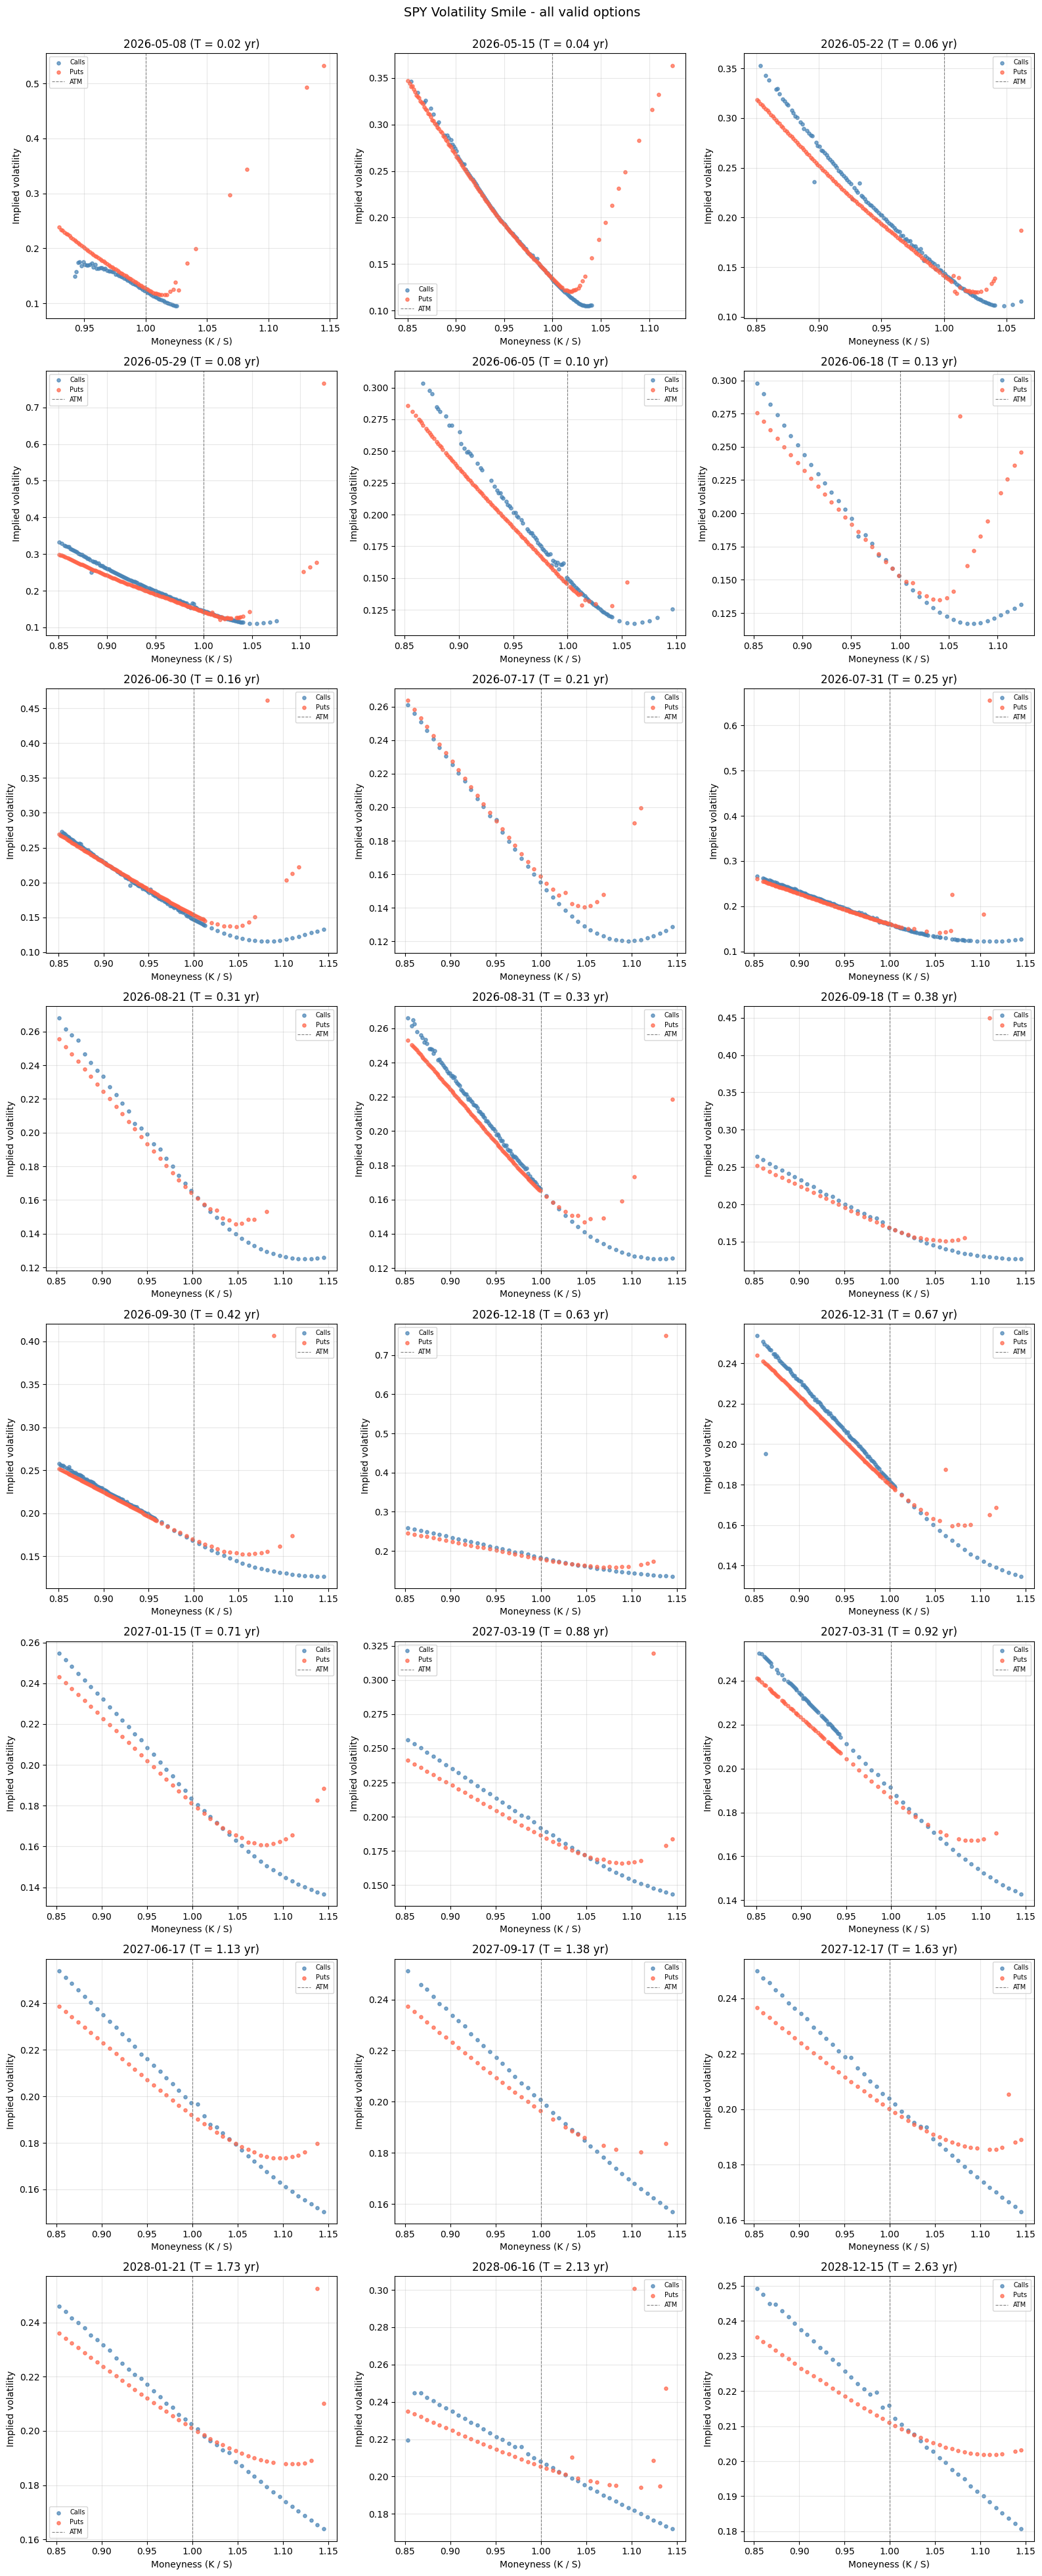

In [7]:
fig, axes = plot_volatility_smiles(iv_all, title="SPY Volatility Smile - all valid options")
plt.show()

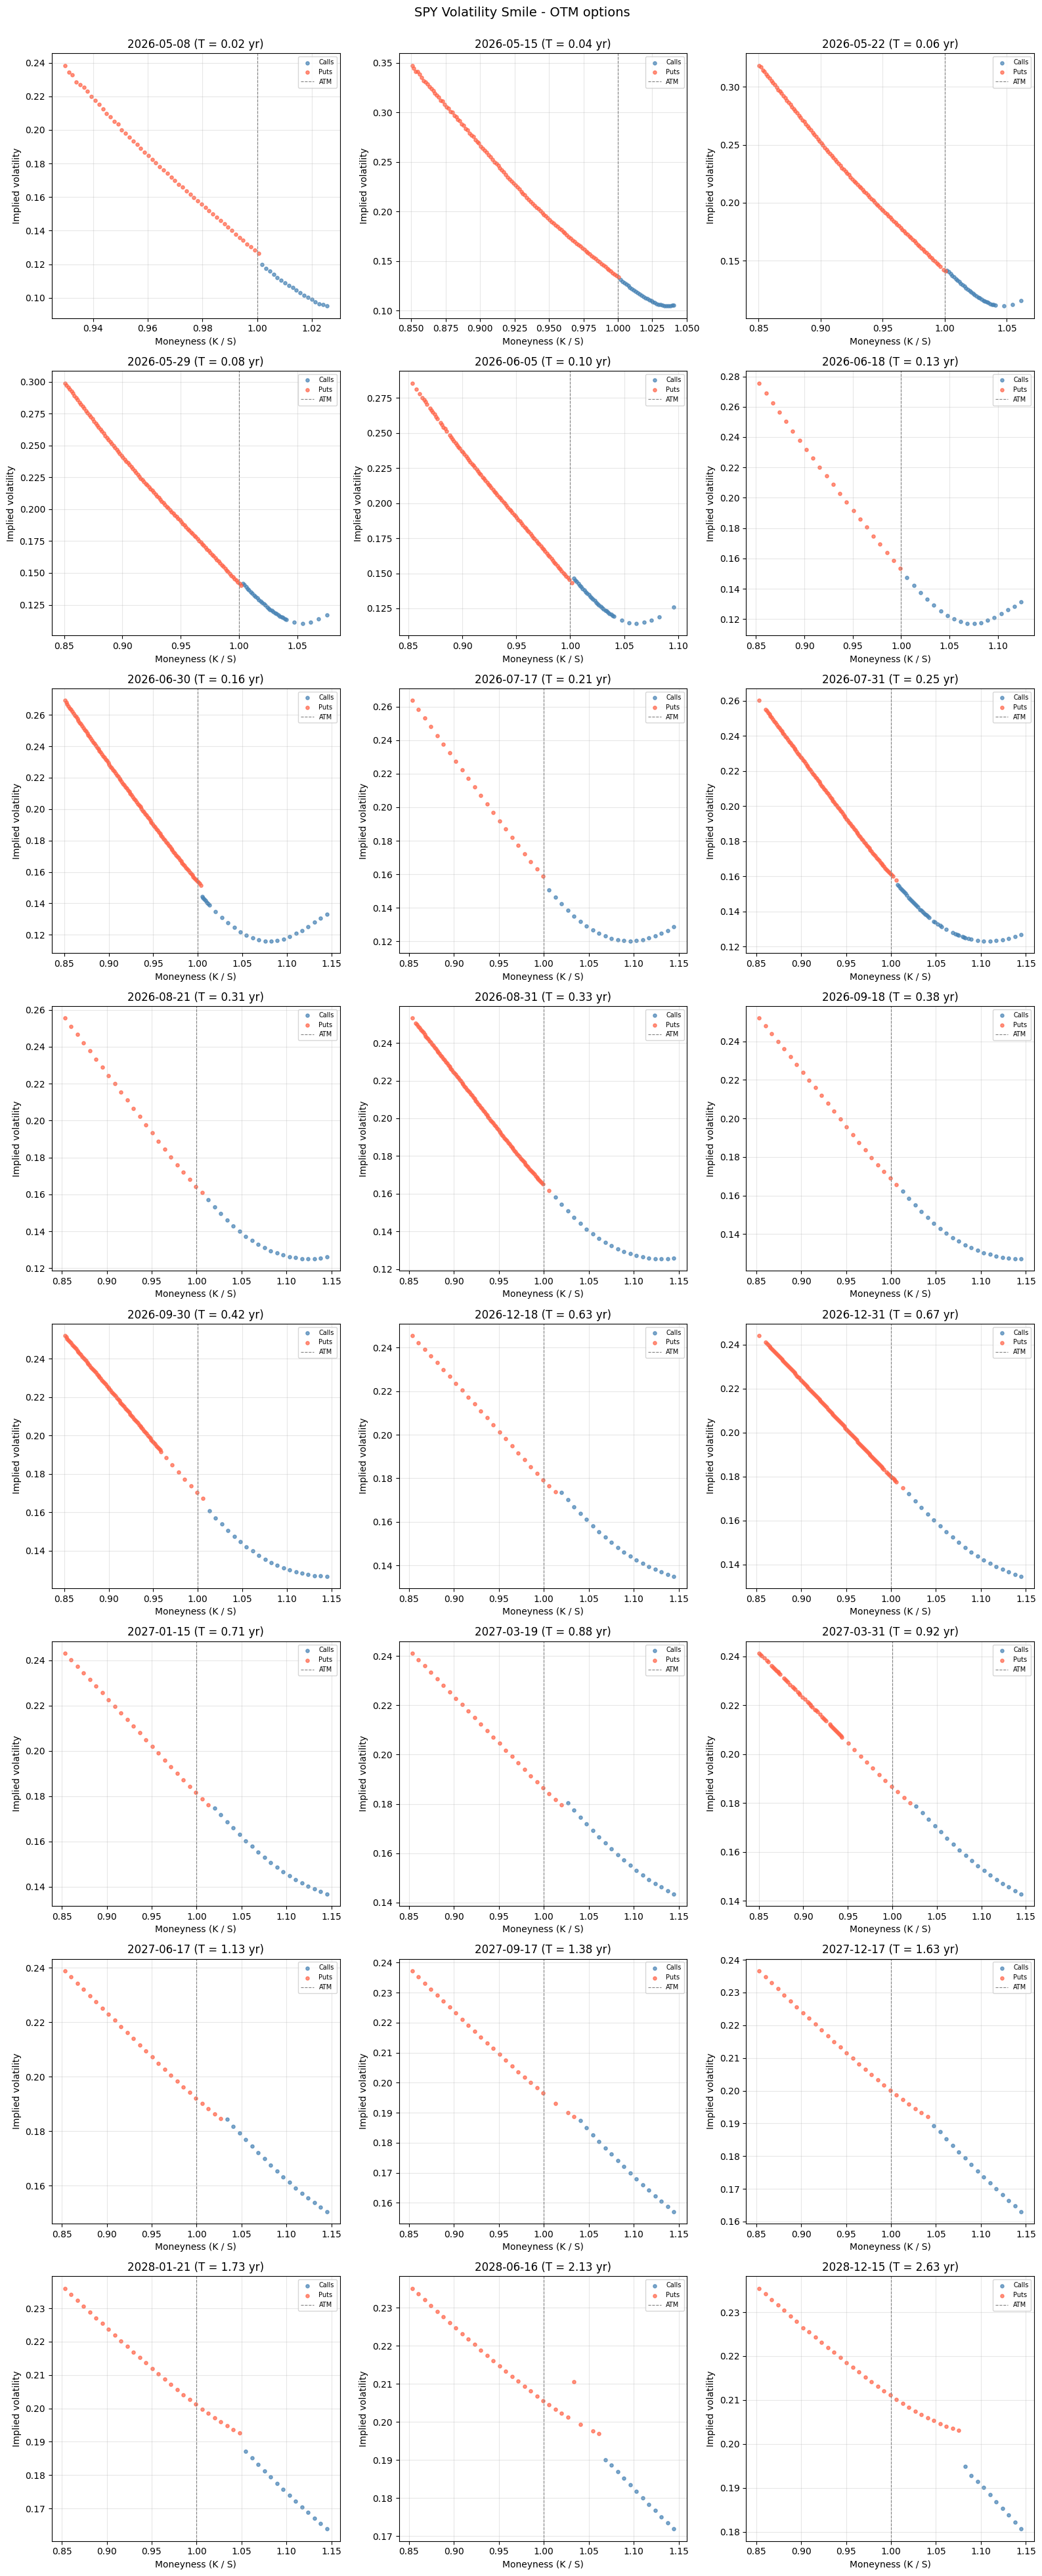

In [8]:
fig, axes = plot_volatility_smiles(iv_otm, title="SPY Volatility Smile - OTM options")
plt.show()

### Volatility Surface View

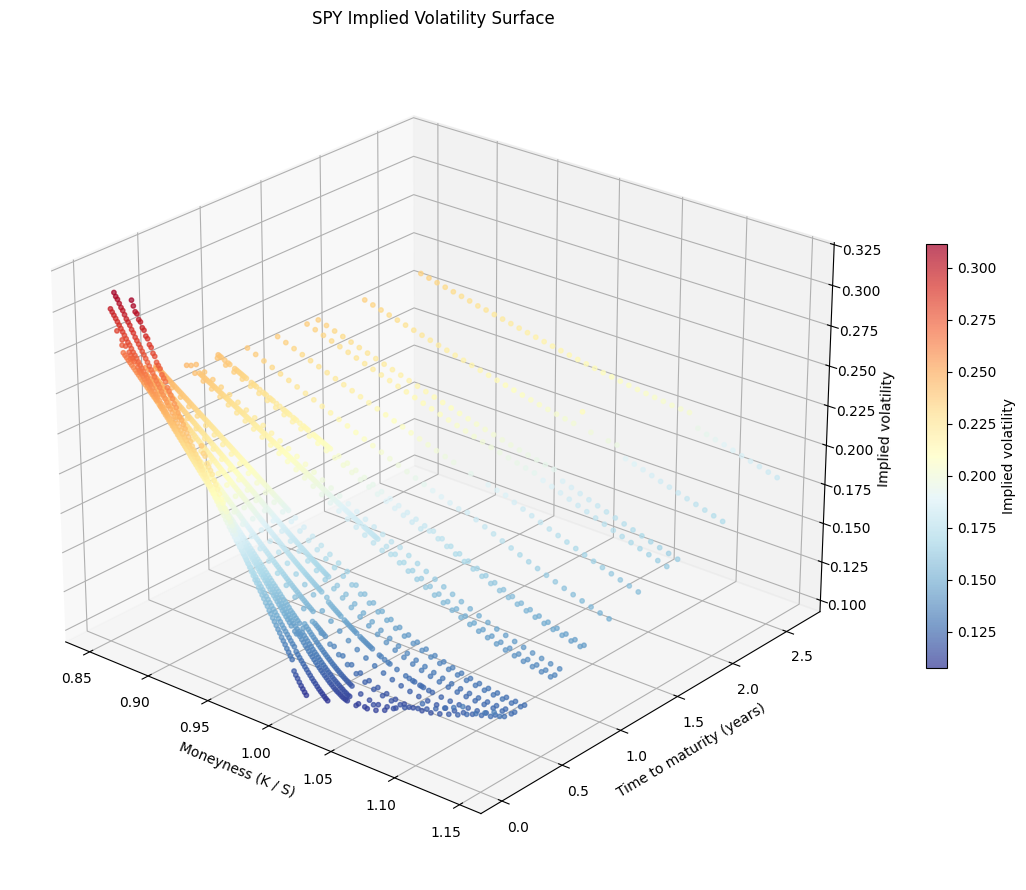

In [9]:
surface_data = iv_otm.copy()
iv_low = surface_data["iv"].quantile(0.01)
iv_high = surface_data["iv"].quantile(0.99)
surface_data = surface_data[(surface_data["iv"] >= iv_low) & (surface_data["iv"] <= iv_high)].copy()

fig, ax = plot_iv_surface_scatter(surface_data)
plt.show()

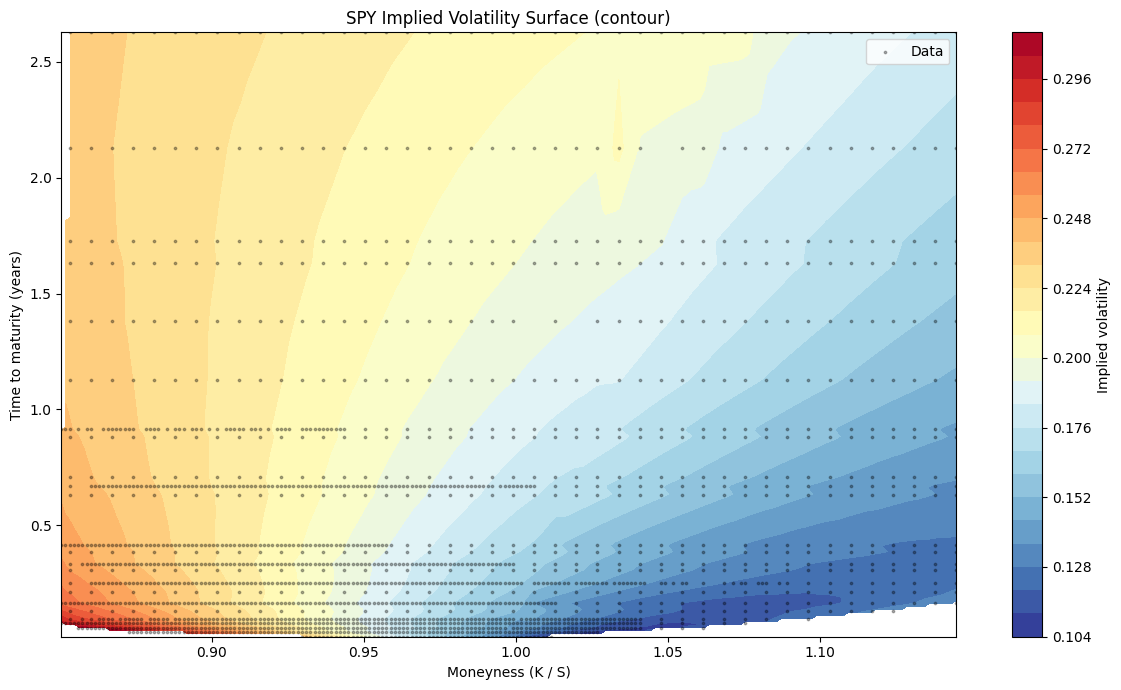

In [10]:
fig, ax = plot_iv_contour(surface_data)
plt.show()

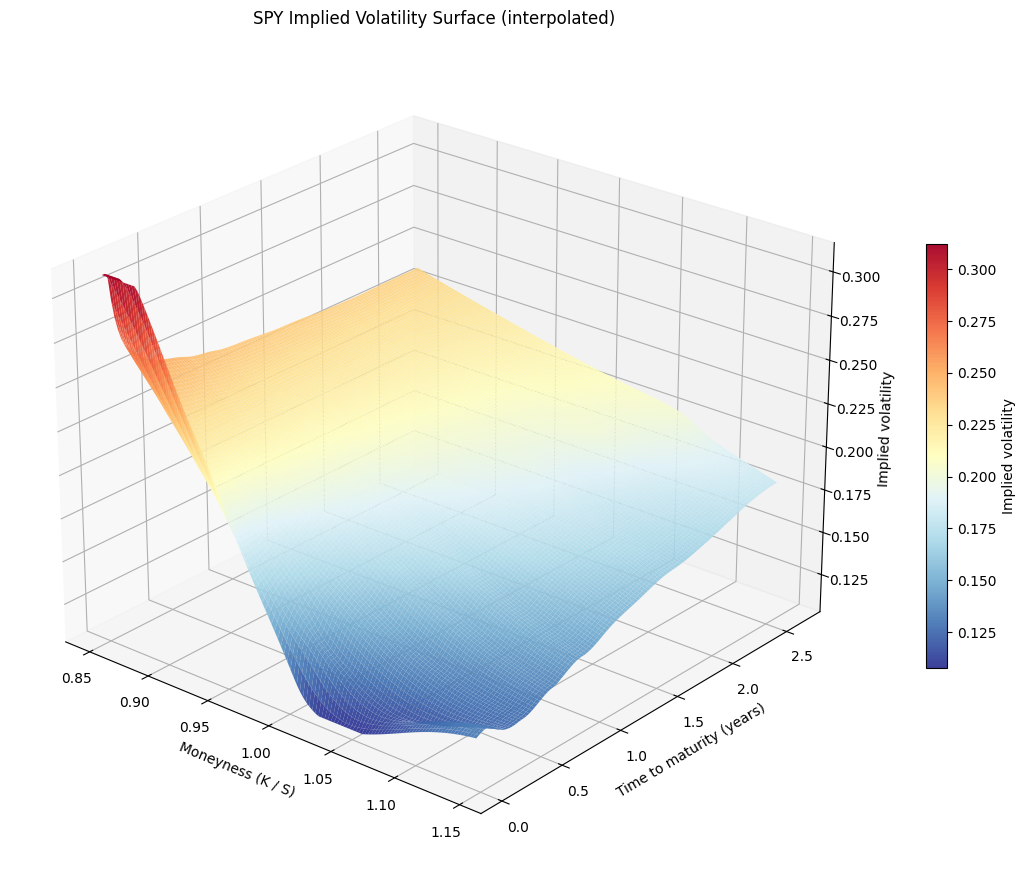

In [11]:
fig, ax = plot_iv_surface_rbf(surface_data, clip=(iv_low, iv_high))
plt.show()

### Final Analysis: Black-Scholes and the Volatility Smile

The implied-volatility plots show that SPY option prices are not consistent with one constant volatility. For a fixed expiry, Black-Scholes would imply a nearly horizontal line: every strike should return approximately the same sigma. Instead, the market surface is strongly strike-dependent. Low-strike options, especially downside puts, generally have higher implied volatility than high-strike calls. This is the classic equity-index skew.

Economically, the skew is not just a numerical artifact. Investors pay for crash protection, market makers demand compensation for selling downside convexity, and equity volatility tends to rise when the index falls. These effects make low-strike puts expensive relative to a flat-volatility Black-Scholes benchmark. The term structure also changes across expiries: short-dated options are more sensitive to current risk and event premia, while longer-dated options average over more possible volatility regimes.

The all-valid-options view is useful because it shows the full listed market: ITM and OTM calls and puts. It also contains more quote noise, especially for very short expiries, deep ITM options, and strikes where intrinsic value dominates time value. The OTM-only view is cleaner for reading the market smile because OTM options are mostly time value and are usually the instruments traders quote when discussing implied volatility.

The conclusion is that Black-Scholes remains useful as a pricing formula, an implied-volatility inverter, and a common quoting language. But as a model of the whole option surface, flat-vol Black-Scholes is too restrictive. The implied-volatility surface is effectively the market repairing the model one option at a time. A better structural model should generate skew, curvature, and term structure directly from its dynamics rather than requiring a separate volatility input for every strike and maturity.